0. Imports and constants

In [1]:
import numpy as np
import matplotlib.ticker as ticker

from numpy.fft import fft2, fftshift
from matplotlib import pyplot as plt

HORIZ_RES = 4096
VERT_RES = 4096

HORIZ_SIZE = 10.0 # m
VERT_SIZE = 10.0  # m
V_s = 343         # m/s

1. Define analysis behavior

In [2]:
w = np.ones(16)

freqs = [1e3, 1e4, 2.4e4]

2. Define array grid

In [3]:
# for now we're just going to use a 4x4 grid

mic_pos = []

# for i in range(4):
#     for j in range(4):
#         # Converting the (i * 8.0 - 12.0) mm spacing into meters:
#         x_m = (i * 16.0 - 24.0) / 1000.0 + HORIZ_SIZE / 2
#         y_m = (j * 16.0 - 24.0) / 1000.0 + VERT_SIZE / 2
#         mic_pos.append([x_m, y_m])

num_mics = 16
r_min = 0.012
r_max = 0.07
turns = 3.0    # Number of spiral rotations
theta_max = turns * 2 * np.pi

# Compute growth rate factor 'a' for log spiral
a = np.log(r_max / r_min) / theta_max

mic_pos = []

for i in range(num_mics):
    # Linearly space the angles across the spiral turns
    theta = (i / (num_mics - 1)) * theta_max
    r = r_min * np.exp(a * theta)
    
    # Calculate Cartesian coordinates
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    mic_pos.append([x, y])

# rad = [0.005 * 1.5**i for i in range(4)]
# num = [4, 4, 4, 4]
# ang_offset = [i * np.pi / 7 for i in range(4)]
# # ang_offset = [0 for i in range(4)]

# for r, n, o in zip(rad, num, ang_offset):
#     theta = 2 * np.pi / n
#     s = np.sin(theta)
#     c = np.cos(theta)
#     rot = np.array([[c, -s], [s, c]])
#     s0 = np.sin(o)
#     c0 = np.cos(o)
#     rot0 = np.array([[c0, -s0], [s0, c0]])
#     pos = np.array([[r], [0]])
#     pos = rot0 @ pos
#     for i in range(n):
#         pos_arr = [pos[0][0], pos[1][0]]
#         mic_pos.append(pos_arr)
#         pos = rot @ pos
        
        

assert len(mic_pos) == len(w)

3. Fourier analysis

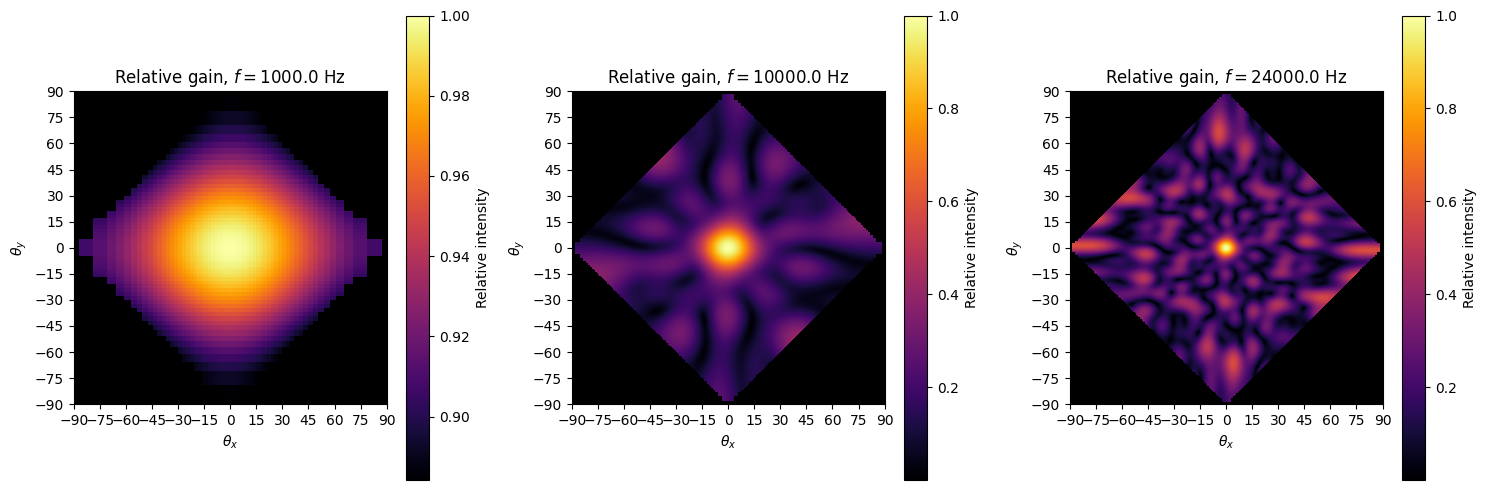

In [4]:
grid = np.zeros((HORIZ_RES, VERT_RES))
for w_n, m_n in zip(w, mic_pos):
    grid_pos = [int(m_n[0] * HORIZ_RES / HORIZ_SIZE), int(m_n[1] * VERT_RES / VERT_SIZE)]
    grid[grid_pos[0], grid_pos[1]] = w_n

X = fftshift(fft2(grid))

fig, axs = plt.subplots(1, len(freqs), figsize=(5 * len(freqs), 5))
if len(freqs) == 1:
    axs = [axs]

deci = [1, 1, 1]

for n, f in enumerate(freqs):
    k = f * 2 * np.pi / V_s
    
    k_x_axis = 2 * np.pi * (np.arange(HORIZ_RES) - HORIZ_RES / 2) / HORIZ_SIZE
    k_y_axis = 2 * np.pi * (np.arange(VERT_RES) - VERT_RES / 2) / VERT_SIZE
    K_X, K_Y = np.meshgrid(k_x_axis, k_y_axis)
    
    temp = k**2 - K_X**2 - K_Y**2
    valid_mask = temp >= 0
    
    angs_x = np.arcsin(np.clip(K_X / k, -1, 1)) * (180 / np.pi) 
    angs_y = np.arcsin(np.clip(K_Y / k, -1, 1)) * (180 / np.pi)
    
    p = np.abs(X)
    p[~valid_mask] = np.nan
    p_masked = np.ma.masked_invalid(p)
    
    max_p = p_masked.max()
    if max_p > 0:
        p_masked /= max_p
        
    # power_mask = p_masked > 1/np.sqrt(2)
    # p_masked[~power_mask] = np.nan
    # p_masked = np.ma.masked_invalid(p_masked)

    ax = axs[n]

    ax.set_aspect('equal')
    ax.set_facecolor('black')

    d = deci[n]
    
    # max_angle = 90
    # ax.set_xlim(-max_angle, max_angle)
    # ax.set_ylim(-max_angle, max_angle)

    tick_spacing = 15 
    ax.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))

    shading = ax.pcolormesh(angs_x[::d, ::d], angs_y[::d, ::d], p_masked[::d, ::d], cmap="inferno", shading="auto")
    
    ax.set_title(f"Relative gain, $f={f}$ Hz")
    ax.set_xlabel(r"$\theta_x$")
    ax.set_ylabel(r"$\theta_y$")

    # C. Turn on matching grid lines to clearly visualize the equal spacing
    # ax.grid(True, color='white', linestyle='--', alpha=0.3)
    
    fig.colorbar(shading, ax=ax, label="Relative intensity")

plt.tight_layout()
plt.show()